<a href="https://colab.research.google.com/github/DevBatra05/Algorithm-for-Intelligent-Systems-and-Robotics-Lab/blob/main/Lab_2_BFS_and_DFS_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Graph structure (adjacency list):
  0: [1, 2]
  1: [0, 3, 4]
  2: [0, 5, 6]
  3: [1]
  4: [1]
  5: [2]
  6: [2]

BFS starting from node 0: [0, 1, 2, 3, 4, 5, 6]
DFS (recursive) starting from node 0: [0, 1, 3, 4, 2, 5, 6]
DFS (iterative) starting from node 0: [0, 1, 3, 4, 2, 5, 6]


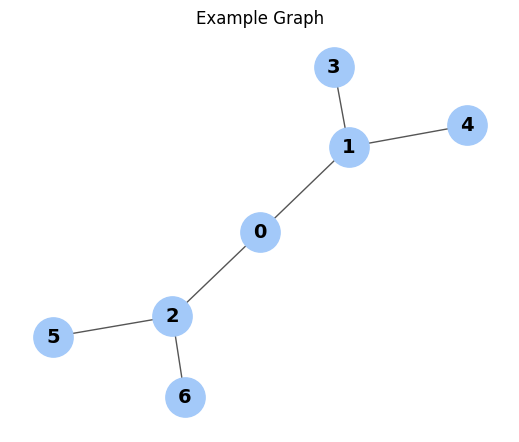

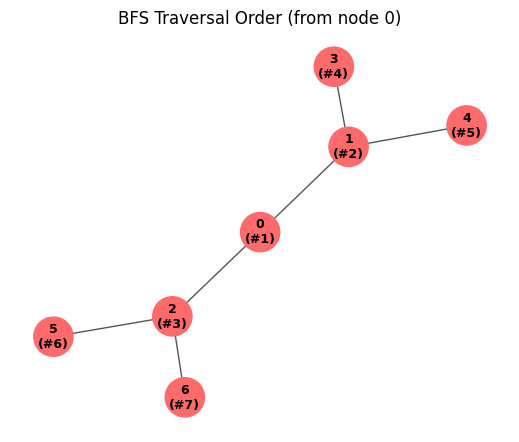

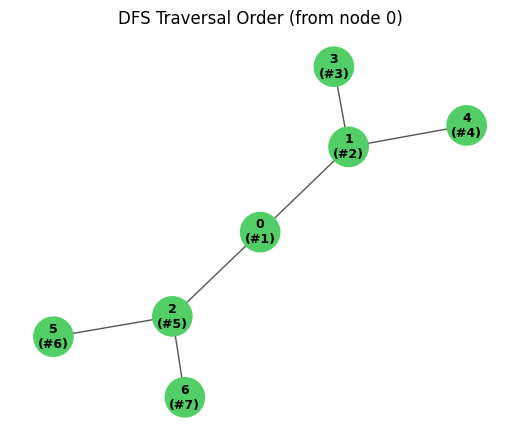


Images saved in Colab's working directory: graph_structure.png, bfs_traversal.png, dfs_traversal.png


In [2]:
from collections import defaultdict, deque
import networkx as nx
import matplotlib.pyplot as plt

class Graph:
    def __init__(self):
        self.graph = defaultdict(list)

    def add_edge(self, u, v):
        self.graph[u].append(v)
        self.graph[v].append(u)  # undirected graph

    def bfs(self, start):
        visited = set([start])
        queue = deque([start])
        order = []
        while queue:
            node = queue.popleft()
            order.append(node)
            for neighbor in sorted(self.graph[node]):
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append(neighbor)
        return order

    def dfs(self, start):
        visited = set()
        order = []
        def dfs_util(node):
            visited.add(node)
            order.append(node)
            for neighbor in sorted(self.graph[node]):
                if neighbor not in visited:
                    dfs_util(neighbor)
        dfs_util(start)
        return order

    def dfs_iterative(self, start):
        visited = set()
        stack = [start]
        order = []
        while stack:
            node = stack.pop()
            if node not in visited:
                visited.add(node)
                order.append(node)
                for neighbor in sorted(self.graph[node], reverse=True):
                    if neighbor not in visited:
                        stack.append(neighbor)
        return order


# ---- Build example graph ----
g = Graph()
edges = [(0,1), (0,2), (1,3), (1,4), (2,5), (2,6)]
for u, v in edges:
    g.add_edge(u, v)

print("Graph structure (adjacency list):")
for node in sorted(g.graph.keys()):
    print(f"  {node}: {sorted(g.graph[node])}")

bfs_order = g.bfs(0)
dfs_order = g.dfs(0)
dfs_iter_order = g.dfs_iterative(0)

print("\nBFS starting from node 0:", bfs_order)
print("DFS (recursive) starting from node 0:", dfs_order)
print("DFS (iterative) starting from node 0:", dfs_iter_order)

# ---- Visualization 1: the graph itself ----
G = nx.Graph()
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(5, 4))
nx.draw(G, pos, with_labels=True, node_color="#a3c9f9", node_size=800,
        font_size=14, font_weight="bold", edge_color="#555555")
plt.title("Example Graph")
plt.savefig("graph_structure.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Visualization 2: BFS traversal order ----
plt.figure(figsize=(5, 4))
colors_bfs = ["#ff6b6b" if n in bfs_order else "#cccccc" for n in G.nodes()]
nx.draw(G, pos, with_labels=False, node_color=colors_bfs, node_size=800, edge_color="#555555")
labels_bfs = {n: f"{n}\n(#{bfs_order.index(n)+1})" for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels_bfs, font_size=9, font_weight="bold")
plt.title("BFS Traversal Order (from node 0)")
plt.savefig("bfs_traversal.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Visualization 3: DFS traversal order ----
plt.figure(figsize=(5, 4))
colors_dfs = ["#51cf66" if n in dfs_order else "#cccccc" for n in G.nodes()]
nx.draw(G, pos, with_labels=False, node_color=colors_dfs, node_size=800, edge_color="#555555")
labels_dfs = {n: f"{n}\n(#{dfs_order.index(n)+1})" for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels_dfs, font_size=9, font_weight="bold")
plt.title("DFS Traversal Order (from node 0)")
plt.savefig("dfs_traversal.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nImages saved in Colab's working directory: graph_structure.png, bfs_traversal.png, dfs_traversal.png")